In [1]:
!pip install tensorflow matplotlib numpy


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import ssl
import os

ssl._create_default_https_context = ssl._create_unverified_context
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['SSL_CERT_FILE'] = ''

In [3]:
train_dir = "data/Val"
val_dir = "data/Val"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 604 images belonging to 4 classes.
Found 604 images belonging to 4 classes.


In [5]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step - accuracy: 0.7649 - loss: 0.7560 - val_accuracy: 0.9437 - val_loss: 0.1795
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.9255 - loss: 0.2001 - val_accuracy: 0.9901 - val_loss: 0.0645
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9619 - loss: 0.1056 - val_accuracy: 0.9917 - val_loss: 0.0394
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 323ms/step - accuracy: 0.9702 - loss: 0.0777 - val_accuracy: 0.9967 - val_loss: 0.0256
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step - accuracy: 0.9752 - loss: 0.0783 - val_accuracy: 0.9983 - val_loss: 0.0190
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step - accuracy: 0.9735 - loss: 0.0781 - val_accuracy: 0.9983 - val_loss: 0.0133
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step - accuracy: 0.9735 - loss: 0.0659 - val_accuracy: 0.9967 - val_loss: 0.0130
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.9884 - loss: 0.0398 - val_accuracy: 1.

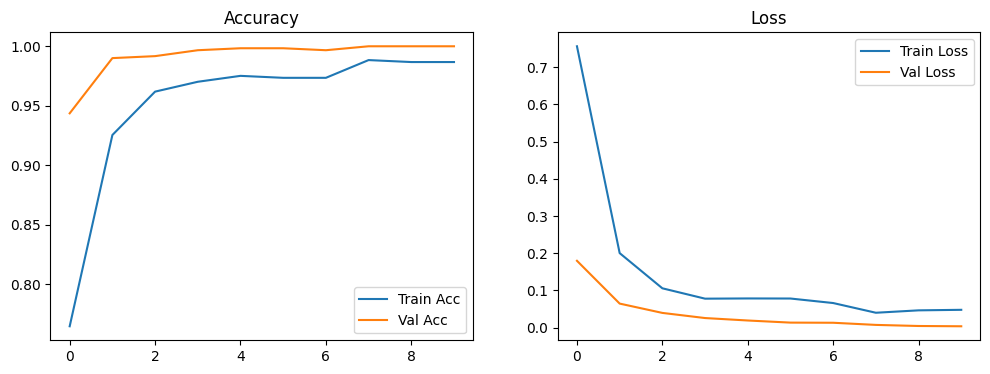

In [9]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [10]:
model.save("mobilenetv2_waste_classifier.h5")


In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [14]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = ['cardboard', 'glass', 'metal', 'plastic']

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print(f"Image: {img_path}")
    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")
    print("-"*30)

In [15]:
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_0_1378782.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_0_1378782.jpg
Prediction: cardboard
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg
Prediction: glass
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg
Prediction: metal
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg
Prediction: plastic
Confidence: 1.00
------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


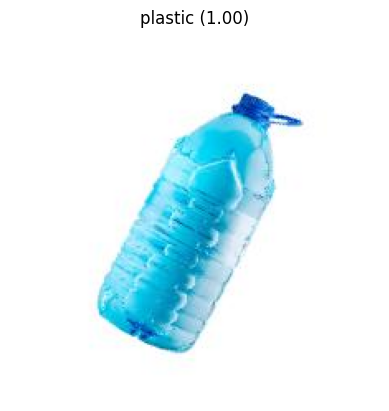

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


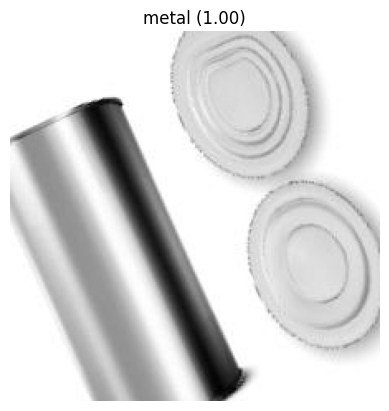

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


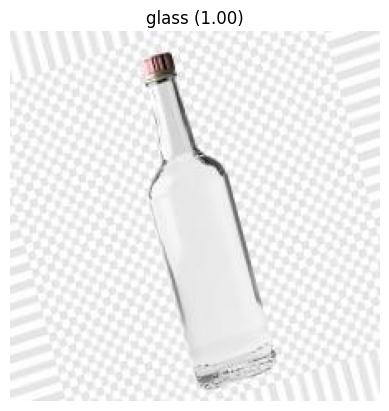

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


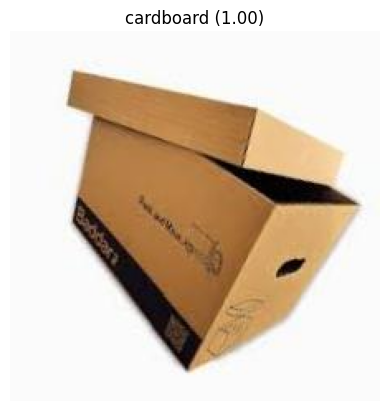

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def show_and_predict(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.title(f"{predicted_class} ({confidence:.2f})")
    plt.show()

show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_1_3274475.jpg")

In [18]:
from keras import layers, Model
import tensorflow as tf

# Inputs
image_input  = tf.keras.Input(shape=(224, 224, 3), name="image_input")
text_input   = tf.keras.Input(shape=(10,), name="text_input")  # حسب MAX_SEQ_LEN

# Image features (مثال بسيط لو مش محمّل EfficientNet)
img_features = layers.Flatten()(image_input)

# Text branch
x = layers.Embedding(21, 64)(text_input)
x = layers.LSTM(128)(x)
text_features = layers.Dense(128, activation='relu')(x)

# Fusion
merged = layers.Concatenate()([img_features, text_features])
merged = layers.Dense(128, activation='relu')(merged)

output = layers.Dense(4, activation='softmax')(merged)

multimodal_model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

In [19]:
from keras.optimizers import Adam

multimodal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
multimodal_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 64)    │      1,344 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 150528)    │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150656)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │ 19,284,096 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │        516 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,401,284 (74.01 MB)

 Trainable params: 19,401,284 (74.01 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor="val_accuracy"
    ),
    ModelCheckpoint(
        "best_model.h5",
        save_best_only=True,
        monitor="val_accuracy"
    )
]

In [22]:
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=10,
    validation_data=val_data,
    validation_steps=len(val_data),
    callbacks=callbacks
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9923 - loss: 0.0338

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step - accuracy: 0.9917 - loss: 0.0390 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.9901 - loss: 0.0356 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9934 - loss: 0.0283 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.9967 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 332ms/step - accuracy: 0.9851 - loss: 0.0429 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 339ms/step - accuracy: 0.9851 - loss: 0.0464 - val_accuracy: 1.0000 - val_loss: 0.0015


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step
              precision    recall  f1-score   support

   cardboard       0.28      0.28      0.28       151
       glass       0.30      0.30      0.30       151
       metal       0.35      0.35      0.35       151
     plastic       0.25      0.25      0.25       151

    accuracy                           0.30       604
   macro avg       0.30      0.30      0.30       604
weighted avg       0.30      0.30      0.30       604



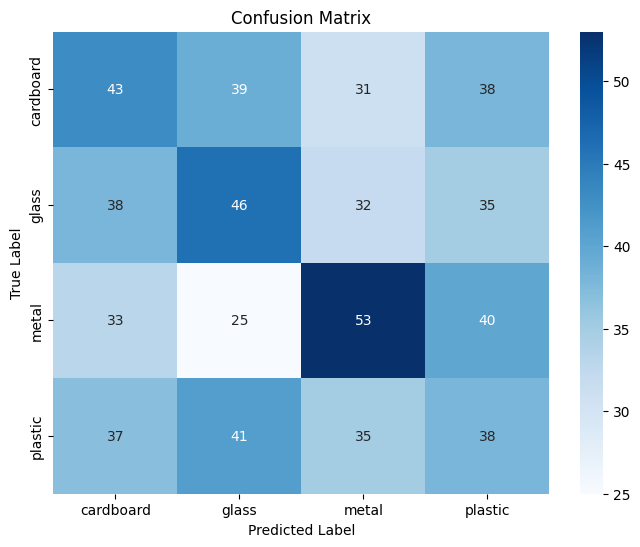

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

val_data.reset()

y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# نفس فكرة bin routing
BIN_ROUTING = {
    'cardboard': ('Blue Bin',   'Paper & Cardboard Recycling'),
    'glass':     ('Green Bin',  'Glass Recycling'),
    'metal':     ('Yellow Bin', 'Metal & Cans Recycling'),
    'plastic':   ('Red Bin',    'Plastic Recycling'),
}

# أسماء الكلاسات من الداتا
CLASS_NAMES = list(train_data.class_indices.keys())

def predict_image_with_bin(img_path):
    # تحميل الصورة
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # prediction
    probs = model.predict(img_batch)[0]

    predicted_idx   = np.argmax(probs)
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence      = probs[predicted_idx]

    bin_name, bin_desc = BIN_ROUTING[predicted_class]

    # 🖨️ output
    print(f"\nWaste Type  : {predicted_class.upper()}")
    print(f"Throw in    : {bin_name} — {bin_desc}")
    print(f"Confidence  : {confidence*100:.1f}%")
    print("─" * 40)

    # bars لكل class
    for name, p in zip(CLASS_NAMES, probs):
        bar = "█" * int(p * 40)
        print(f"  {name:<12} {p*100:5.1f}%  {bar}")

    # عرض الصورة
    plt.imshow(img)
    plt.title(f"{predicted_class.upper()} → {bin_name}\n({confidence*100:.1f}%)")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Waste Type  : CARDBOARD
Throw in    : Blue Bin — Paper & Cardboard Recycling
Confidence  : 100.0%
────────────────────────────────────────
  cardboard    100.0%  ███████████████████████████████████████
  glass          0.0%  
  metal          0.0%  
  plastic        0.0%  


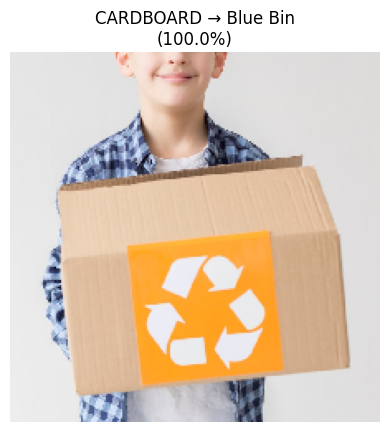

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Waste Type  : GLASS
Throw in    : Green Bin — Glass Recycling
Confidence  : 100.0%
────────────────────────────────────────
  cardboard      0.0%  
  glass        100.0%  ███████████████████████████████████████
  metal          0.0%  
  plastic        0.0%  


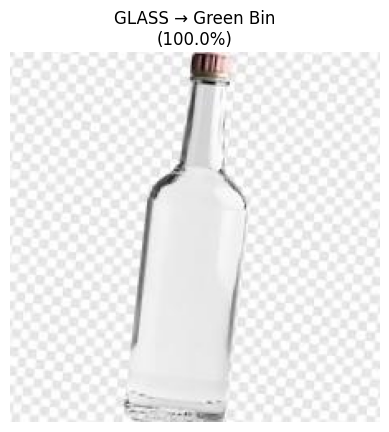

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Waste Type  : METAL
Throw in    : Yellow Bin — Metal & Cans Recycling
Confidence  : 99.8%
────────────────────────────────────────
  cardboard      0.0%  
  glass          0.2%  
  metal         99.8%  ███████████████████████████████████████
  plastic        0.0%  


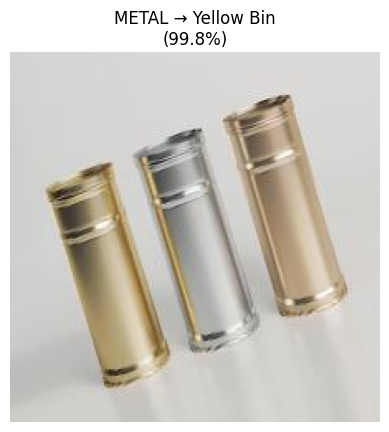

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Waste Type  : CARDBOARD
Throw in    : Blue Bin — Paper & Cardboard Recycling
Confidence  : 100.0%
────────────────────────────────────────
  cardboard    100.0%  ███████████████████████████████████████
  glass          0.0%  
  metal          0.0%  
  plastic        0.0%  


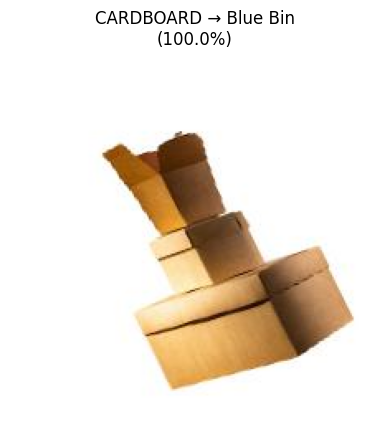

In [31]:
predict_image_with_bin("/Users/ameer/Desktop/Healix-main/raw/cardboard/image_132.jpg")
predict_image_with_bin("data/Val/glass/aug_0_4681832.jpg")
predict_image_with_bin("/Users/ameer/Desktop/Healix-main/data/Val/metal/aug_5_8254956.jpg")
predict_image_with_bin("data/Val/cardboard/aug_11_8301770.jpg")